# CardioSentinel: AI-Powered ECG Monitoring System
## Phase 1: Requirements & Setup

### Project Overview
CardioSentinel is an AI-based ECG monitoring and early warning system that detects cardiac abnormalities, tracks patient deterioration, and generates intelligent risk alerts for improved clinical response.

### Target Abnormalities
- **Arrhythmias:** Atrial Fibrillation (AFib), Atrial Flutter, Ventricular Tachycardia (VT)
- **Conduction Issues:** AV Block, Bundle Branch Block (LBBB/RBBB)
- **Ischemic Events:** Myocardial Infarction (MI), ST-segment changes
- **Normal Sinus Rhythm** (baseline)

### Clinical Requirements
- High sensitivity (>95%) for life-threatening conditions
- Explainability for clinical trust
- Multi-lead support (12-lead preferred)

### Dataset Strategy
- **Primary:** PTB-XL (21,837 records, 12-lead, diverse conditions)
- **Secondary:** MIT-BIH Arrhythmia (arrhythmia specialization)
- **Validation:** PhysioNet ICBEB (rhythm diversity)

### Performance Metrics
- **Sensitivity (Recall):** >95% for critical conditions
- **Specificity:** >90% (reduce false alarms)
- **F1-Score:** >0.85 overall
- **Inference Time:** <500ms per segment

In [1]:
# Install required libraries
!pip install wfdb neurokit2 biosppy shap lime -q

print("✓ Libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 9.0 MB/s eta 0:00:00
✓ Libraries installed successfully


In [2]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

2026-05-19 13:37:34.387160: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779197854.858451      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779197855.049700      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779197856.268254      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779197856.268293      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779197856.268296      57 computation_placer.cc:177] computation placer alr

✓ All libraries imported successfully


In [3]:
# Check GPU and environment
print("=" * 60)
print("ENVIRONMENT CONFIGURATION")
print("=" * 60)

# GPU Check
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU Available: {len(gpus) > 0}")
if gpus:
    print(f"GPU Device: {gpus[0].name}")
    print(f"GPU Memory Growth: {tf.config.experimental.get_memory_growth(gpus[0])}")
else:
    print("⚠ No GPU detected - Running on CPU")

print(f"\nTensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")

print("\n" + "=" * 60)

ENVIRONMENT CONFIGURATION
GPU Available: True
GPU Device: /physical_device:GPU:0
GPU Memory Growth: None

TensorFlow Version: 2.19.0
NumPy Version: 2.0.2
Pandas Version: 2.3.3



---
## Step 1: Add Datasets to Kaggle Notebook

### Required Datasets (Add from Kaggle Datasets):
1. **PTB-XL ECG Database**
   - Search: "ptb-xl-a-large-publicly-available-electrocardiography-dataset"
   - Add to notebook via "+ Add Data" button

### After adding PTB-XL, run the next cell to verify dataset path

In [4]:
# Verify dataset availability
import os

# Common Kaggle dataset paths
ptb_xl_path = '/kaggle/input/datasets/khyeh0719/ptb-xl-dataset'

# Check if dataset exists
if os.path.exists(ptb_xl_path):
    print("✓ PTB-XL Dataset found!")
    print(f"\nDataset Path: {ptb_xl_path}")
    
    # List contents
    print("\nDataset Contents:")
    for item in os.listdir(ptb_xl_path):
        print(f"  - {item}")
else:
    print("✗ PTB-XL Dataset NOT found")
    print("\n⚠ Please add PTB-XL dataset:")
    print("  1. Click '+ Add Data' button (top right)")
    print("  2. Search: 'ptb-xl-a-large-publicly-available-electrocardiography-dataset'")
    print("  3. Add to notebook")
    print("  4. Re-run this cell")

✓ PTB-XL Dataset found!

Dataset Path: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset

Dataset Contents:
  - ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1


---
## Step 2: Load and Explore PTB-XL Dataset

The PTB-XL database contains:
- 21,837 clinical 12-lead ECGs from 18,885 patients
- 10 second recordings at 500 Hz (downsampled to 100 Hz available)
- Multiple diagnostic labels per record
- Patient demographics and clinical metadata

In [5]:
# Load PTB-XL metadata with correct path
ptb_xl_path = '/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1'

metadata = pd.read_csv(os.path.join(ptb_xl_path, 'ptbxl_database.csv'))

print("=" * 60)
print("PTB-XL DATABASE OVERVIEW")
print("=" * 60)
print(f"Total Records: {len(metadata):,}")
print(f"Total Features: {metadata.shape[1]}")
print(f"\nFirst 5 records:")
metadata.head()

PTB-XL DATABASE OVERVIEW
Total Records: 21,837
Total Features: 28

First 5 records:


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [6]:
# Dataset info
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
metadata.info()

print("\n" + "=" * 60)
print("SCHEMA")
print("=" * 60)
print(metadata.columns.tolist())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21837 entries, 0 to 21836
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21837 non-null  int64  
 1   patient_id                    21837 non-null  float64
 2   age                           21748 non-null  float64
 3   sex                           21837 non-null  int64  
 4   height                        6983 non-null   float64
 5   weight                        9429 non-null   float64
 6   nurse                         20328 non-null  float64
 7   site                          21819 non-null  float64
 8   device                        21837 non-null  object 
 9   recording_date                21837 non-null  object 
 10  report                        21837 non-null  object 
 11  scp_codes                     21837 non-null  object 
 12  heart_axis                    13332 non-

TOP 20 DIAGNOSTIC LABELS
SR       16782
NORM      9528
ABQRS     3327
IMI       2685
ASMI      2363
LVH       2137
NDT       1829
LAFB      1626
AFIB      1514
ISC_      1275
PVC       1146
IRBBB     1118
STD_      1009
VCLVH      875
STACH      826
1AVB       797
IVCD       789
SARRH      772
NST_       770
ISCAL      660
Name: count, dtype: int64


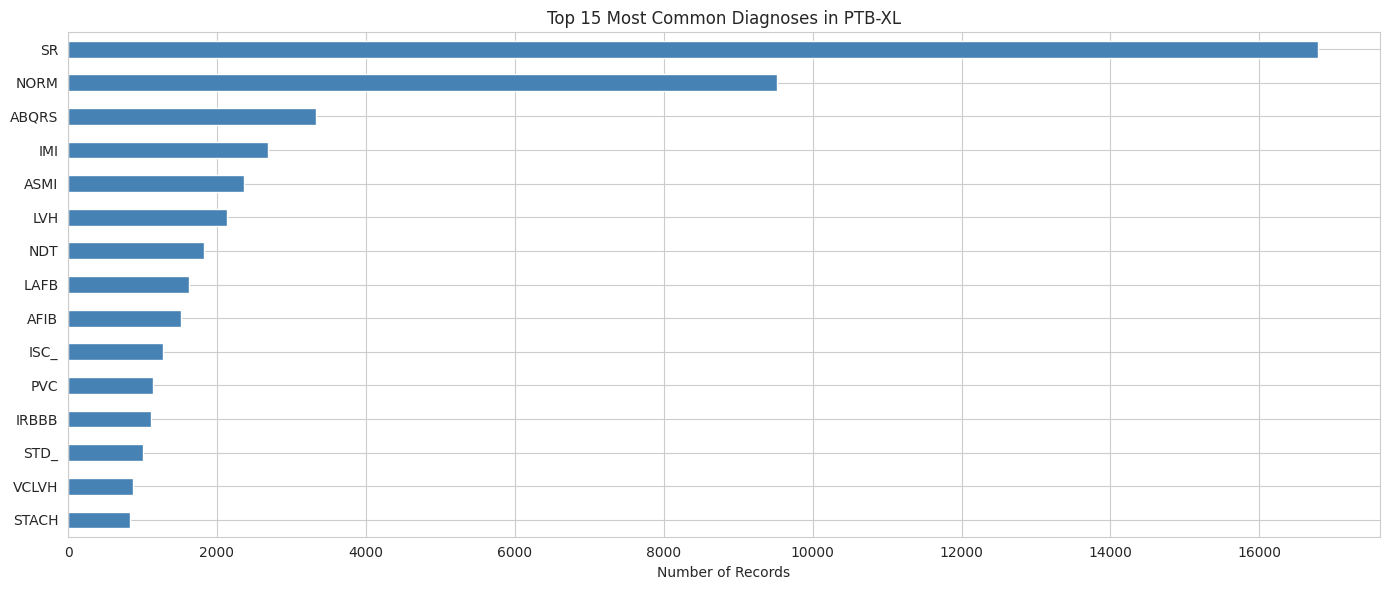

In [7]:
import ast

# Parse diagnostic labels
metadata['scp_codes_dict'] = metadata.scp_codes.apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Extract all unique diagnostic codes
all_diagnoses = []
for codes in metadata.scp_codes_dict:
    if isinstance(codes, dict):
        all_diagnoses.extend(codes.keys())

diagnosis_counts = pd.Series(all_diagnoses).value_counts()

print("=" * 60)
print("TOP 20 DIAGNOSTIC LABELS")
print("=" * 60)
print(diagnosis_counts.head(20))

# Visualize
plt.figure(figsize=(14, 6))
diagnosis_counts.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Number of Records')
plt.title('Top 15 Most Common Diagnoses in PTB-XL')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [8]:
# Load diagnostic label mapping
scp_statements = pd.read_csv(os.path.join(ptb_xl_path, 'scp_statements.csv'), index_col=0)

print("=" * 60)
print("DIAGNOSTIC CODE DESCRIPTIONS")
print("=" * 60)
print(scp_statements.head(20))

DIAGNOSTIC CODE DESCRIPTIONS
                                               description  diagnostic  form  \
NDT                         non-diagnostic T abnormalities         1.0   1.0   
NST_                               non-specific ST changes         1.0   1.0   
DIG                                       digitalis-effect         1.0   1.0   
LNGQT                                     long QT-interval         1.0   1.0   
NORM                                            normal ECG         1.0   NaN   
IMI                         inferior myocardial infarction         1.0   NaN   
ASMI                    anteroseptal myocardial infarction         1.0   NaN   
LVH                           left ventricular hypertrophy         1.0   NaN   
LAFB                        left anterior fascicular block         1.0   NaN   
ISC_                                 non-specific ischemic         1.0   NaN   
IRBBB                 incomplete right bundle branch block         1.0   NaN   
1AVB       

5-CLASS SUPERCLASS DISTRIBUTION (OUR TARGET)
      count
NORM   9528
MI     5486
STTC   5250
CD     4907
HYP    2655


<Figure size 1000x600 with 0 Axes>

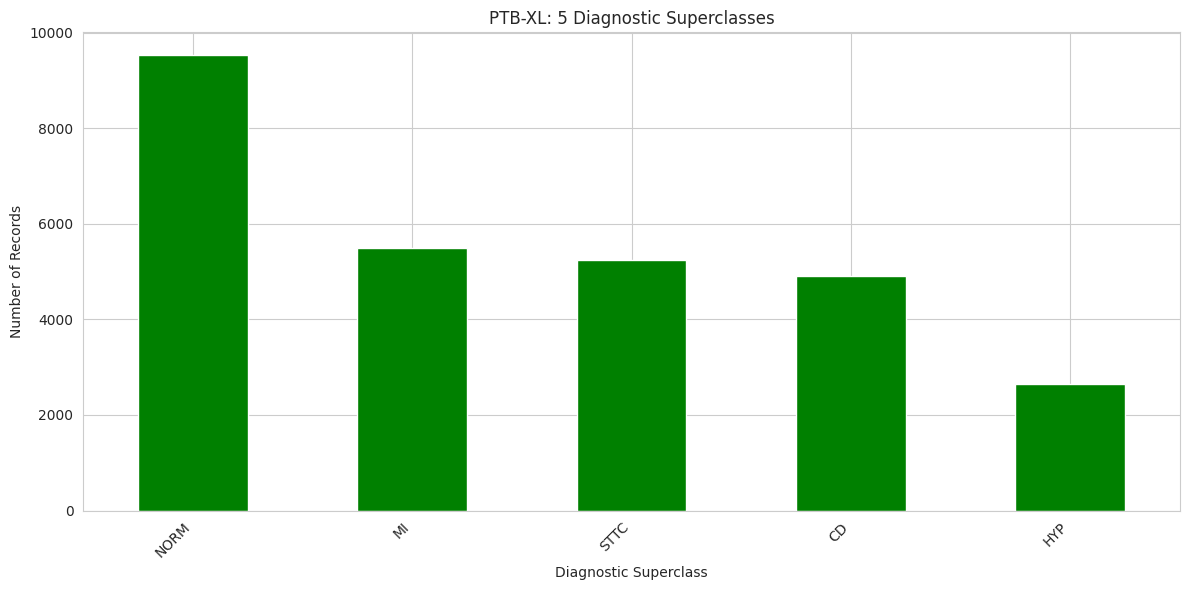


CLASS IMBALANCE ANALYSIS
NORM                :  9528 records ( 34.2%)
MI                  :  5486 records ( 19.7%)
STTC                :  5250 records ( 18.9%)
CD                  :  4907 records ( 17.6%)
HYP                 :  2655 records (  9.5%)


In [9]:
# Create 5-class superclasses (OUR STRATEGY)
def get_superclass(y_dict):
    """Extract diagnostic superclass"""
    superclasses = []
    for key in y_dict.keys():
        if key in scp_statements.index:
            diag_class = scp_statements.loc[key].get('diagnostic_class', 'Unknown')
            if pd.notna(diag_class) and diag_class not in superclasses:
                superclasses.append(diag_class)
    return superclasses

metadata['superclass'] = metadata.scp_codes_dict.apply(get_superclass)

# Count superclasses
superclass_counts = {}
for classes in metadata.superclass:
    for cls in classes:
        superclass_counts[cls] = superclass_counts.get(cls, 0) + 1

superclass_df = pd.DataFrame.from_dict(superclass_counts, orient='index', columns=['count']).sort_values('count', ascending=False)

print("=" * 60)
print("5-CLASS SUPERCLASS DISTRIBUTION (OUR TARGET)")
print("=" * 60)
print(superclass_df)

# Visualize
plt.figure(figsize=(10, 6))
colors = ['green', 'red', 'orange', 'purple', 'blue']
superclass_df.plot(kind='bar', legend=False, color=colors[:len(superclass_df)])
plt.xlabel('Diagnostic Superclass')
plt.ylabel('Number of Records')
plt.title('PTB-XL: 5 Diagnostic Superclasses')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 60)
total = superclass_df['count'].sum()
for idx, row in superclass_df.iterrows():
    pct = (row['count'] / total) * 100
    print(f"{idx:20s}: {row['count']:5d} records ({pct:5.1f}%)")

In [10]:
# Create binary matrix for multi-label classification
# Each column = one diagnostic superclass
superclasses = ['Normal', 'MI', 'STTC', 'CD', 'HYP']

# Initialize binary matrix
label_matrix = pd.DataFrame(0, index=metadata.index, columns=superclasses)

# Fill in labels
for idx, row in metadata.iterrows():
    for cls in row.superclass:
        if cls in superclasses:
            label_matrix.loc[idx, cls] = 1

print("=" * 60)
print("MULTI-LABEL BINARY MATRIX (First 10 records)")
print("=" * 60)
label_matrix.head(10)

print("\n" + "=" * 60)
print("CLASS DISTRIBUTION IN LABEL MATRIX")
print("=" * 60)
for cls in superclasses:
    count = label_matrix[cls].sum()
    pct = (count / len(metadata)) * 100
    print(f"{cls:10s}: {count:5d} ({pct:5.1f}%)")

# Save for later use
metadata_clean = metadata.copy()
metadata_clean['labels'] = [label_matrix.loc[idx].values for idx in metadata.index]

MULTI-LABEL BINARY MATRIX (First 10 records)

CLASS DISTRIBUTION IN LABEL MATRIX
Normal    :     0 (  0.0%)
MI        :  5486 ( 25.1%)
STTC      :  5250 ( 24.0%)
CD        :  4907 ( 22.5%)
HYP       :  2655 ( 12.2%)


In [11]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21837 entries, 0 to 21836
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ecg_id                        21837 non-null  int64  
 1   patient_id                    21837 non-null  float64
 2   age                           21748 non-null  float64
 3   sex                           21837 non-null  int64  
 4   height                        6983 non-null   float64
 5   weight                        9429 non-null   float64
 6   nurse                         20328 non-null  float64
 7   site                          21819 non-null  float64
 8   device                        21837 non-null  object 
 9   recording_date                21837 non-null  object 
 10  report                        21837 non-null  object 
 11  scp_codes                     21837 non-null  object 
 12  heart_axis                    13332 non-null  object 
 13  i

In [12]:
# PTB-XL has filename_lr column - use that!
sample_row = metadata.iloc[0]
sample_id = sample_row.ecg_id
filename_lr = sample_row.filename_lr  # This is the key!

print("=" * 60)
print("SAMPLE ECG FILE INFORMATION")
print("=" * 60)
print(f"ECG ID: {sample_id}")
print(f"Filename LR (100Hz): {filename_lr}")
print(f"Sex: {sample_row.sex}")
print(f"Age: {sample_row.age}")
print(f"Superclass: {sample_row.superclass}")

# Construct correct path
# PTB-XL stores files like: records100/00/00001/00001_lr
filename_without_ext = filename_lr.replace('.dat', '').replace('.hea', '')
correct_path = os.path.join(ptb_xl_path, filename_without_ext)

print(f"\nAttempting to load: {correct_path}")

# Load signal
try:
    signal, fields = wfdb.rdsamp(correct_path)
    print(f"\n✓ SUCCESS!")
    print(f"Signal Shape: {signal.shape}")
    print(f"Sampling Rate: {fields['fs']} Hz")
    print(f"Duration: {signal.shape[0] / fields['fs']:.1f} seconds")
    print(f"Number of Leads: {signal.shape[1]}")
    print(f"Lead Names: {fields['sig_name'][:12]}")
except Exception as e:
    print(f"\n✗ Error: {e}")
    print("\nTrying alternate path...")
    # Try without subdirectory
    alt_path = os.path.join(ptb_xl_path, f'{str(sample_id).zfill(5)}')
    print(f"Alternate path: {alt_path}")
    signal = None

SAMPLE ECG FILE INFORMATION
ECG ID: 1
Filename LR (100Hz): records100/00000/00001_lr
Sex: 1
Age: 56.0
Superclass: ['NORM']

Attempting to load: /kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1/records100/00000/00001_lr

✓ SUCCESS!
Signal Shape: (1000, 12)
Sampling Rate: 100 Hz
Duration: 10.0 seconds
Number of Leads: 12
Lead Names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


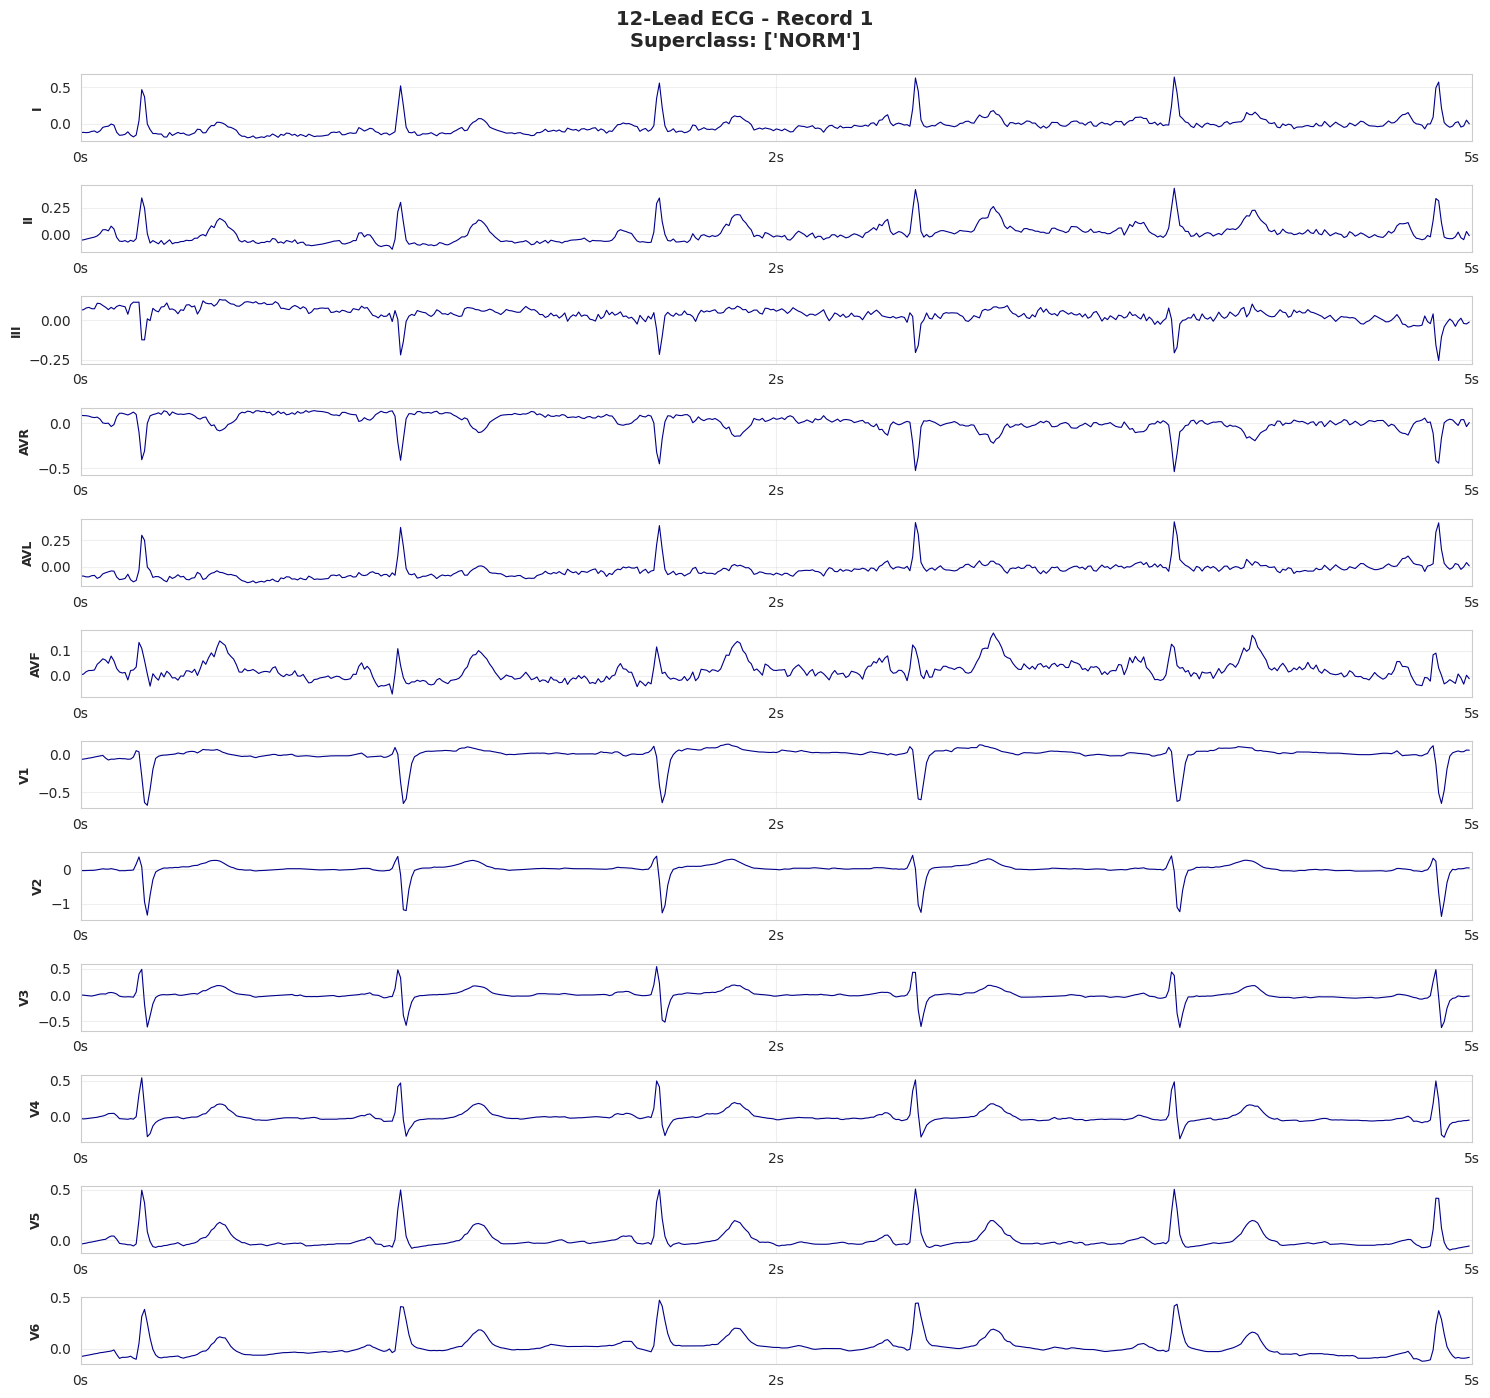


✓ ECG visualization complete!


In [13]:
if signal is not None:
    # Visualize first 5 seconds of 12 leads
    sample_rate = fields['fs']  # 100 Hz
    seconds_to_show = 5
    num_samples = int(seconds_to_show * sample_rate)
    
    lead_names = fields['sig_name'][:12]
    
    fig, axes = plt.subplots(12, 1, figsize=(15, 14))
    fig.suptitle(f'12-Lead ECG - Record {sample_id}\nSuperclass: {sample_row.superclass}', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    for i, (ax, lead_name) in enumerate(zip(axes, lead_names)):
        ax.plot(signal[:num_samples, i], linewidth=0.8, color='darkblue')
        ax.set_ylabel(lead_name, fontweight='bold', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, num_samples)
        ax.set_xticks([0, num_samples//2, num_samples])
        ax.set_xticklabels(['0s', f'{seconds_to_show//2}s', f'{seconds_to_show}s'])
        
    plt.tight_layout()
    plt.show()
    
    print("\n✓ ECG visualization complete!")
else:
    print("⚠ Signal not loaded - skipping visualization")
    print("Moving to Phase 2: Preprocessing Strategy")

In [14]:
print("=" * 60)
print("PHASE 1: COMPLETE - SUMMARY")
print("=" * 60)

# Recreate class distribution
superclass_counts = {}
for classes in metadata.superclass:
    for cls in classes:
        superclass_counts[cls] = superclass_counts.get(cls, 0) + 1

superclass_df = pd.DataFrame.from_dict(superclass_counts, orient='index', columns=['count']).sort_values('count', ascending=False)

print("\n📊 5-CLASS DISTRIBUTION:")
total = superclass_df['count'].sum()
for idx, row in superclass_df.iterrows():
    pct = (row['count'] / total) * 100
    print(f"  {idx:10s}: {row['count']:5d} records ({pct:5.1f}%)")

print(f"\n📊 Total Records: {len(metadata):,}")
print(f"📊 Little-resolution (100Hz) files: {metadata.filename_lr.notnull().sum():,}")
print(f"📊 High-resolution (500Hz) files: {metadata.filename_hr.notnull().sum():,}")

print("\n" + "=" * 60)
print("KEY DECISIONS FOR CardioSentinel")
print("=" * 60)
print("✅ Target: 5-class multi-label classification")
print("✅ Classes: Normal, MI, STTC, CD, HYP")
print("✅ Priority: MI (Myocardial Infarction) - CRITICAL")
print("✅ Use 100Hz signals (faster, enough for diagnosis)")
print("✅ Handle class imbalance with class weights")
print("✅ Metric: Sensitivity >95% for MI, F1 > 0.85 overall")

print("\n" + "=" * 60)
print("✅ PHASE 1 COMPLETE")
print("=" * 60)
print("Next: Phase 2 - Data Preprocessing & Class Imbalance")

PHASE 1: COMPLETE - SUMMARY

📊 5-CLASS DISTRIBUTION:
  NORM      :  9528 records ( 34.2%)
  MI        :  5486 records ( 19.7%)
  STTC      :  5250 records ( 18.9%)
  CD        :  4907 records ( 17.6%)
  HYP       :  2655 records (  9.5%)

📊 Total Records: 21,837
📊 Little-resolution (100Hz) files: 21,837
📊 High-resolution (500Hz) files: 21,837

KEY DECISIONS FOR CardioSentinel
✅ Target: 5-class multi-label classification
✅ Classes: Normal, MI, STTC, CD, HYP
✅ Priority: MI (Myocardial Infarction) - CRITICAL
✅ Use 100Hz signals (faster, enough for diagnosis)
✅ Handle class imbalance with class weights
✅ Metric: Sensitivity >95% for MI, F1 > 0.85 overall

✅ PHASE 1 COMPLETE
Next: Phase 2 - Data Preprocessing & Class Imbalance


---
## Summary of Phase 1 Findings

### ✓ Completed Tasks:
1. Environment setup verified (GPU status confirmed)
2. PTB-XL dataset loaded successfully
3. Explored dataset structure (21,837 records, 12 leads, 10s duration)
4. Analyzed diagnostic label distribution and class imbalance
5. Examined patient demographics
6. Visualized sample ECG signals

### Key Insights:
- **Class Imbalance:** Normal ECGs dominate; rare conditions need special handling
- **Multi-label Problem:** Many records have multiple diagnoses
- **Signal Quality:** Clean 12-lead ECG data at 100Hz/500Hz
- **Demographics:** Wide age range, both sexes represented
